# Deconvolve the replicating timing for the 10k bin curves using the Haar wavelet for a step-wise result

April 30, 2024

Compute the replicating timing from the deconvolved MNase-seq 10k windows for each gene.

**Goal:** Deconvolve the replication timing such that the result is a step-wise function
from G1 of copy number 1, S-phase (transition from 1 to 2 step-wise), and G2M as copy number 2.


In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()
mnase_analysis_rep1.compute_replication_timing()


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:29.261


In [221]:
mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()
mnase_analysis_rep2.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:43.759


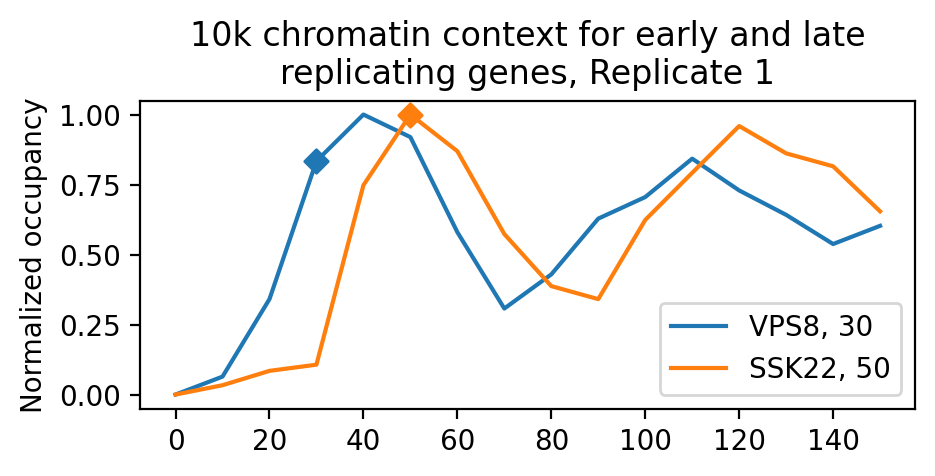

In [6]:
mnase_analysis_rep1.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [325]:
from src.geneset import get_deconvolved_geneset

def get_g_for_chrom(mnase_analysis, chrom):
    """Get the g curve for deconvolution for a chromosome"""
    geneset = get_deconvolved_geneset()

    chr_genes = geneset[geneset.chr == chrom]
    chr_curves = mnase_analysis.normalized_bin_curves.join(chr_genes[[]], how='inner')
    g = chr_curves.values.T

    # Add 1 to enforce copy number values 1-2, also easier to deconvolve values
    # away from 0.
    g = g + 1.
    return g, chr_genes

chrom = 10
g1, chr_genes = get_g_for_chrom(mnase_analysis_rep1, chrom)
g2, chr_genes = get_g_for_chrom(mnase_analysis_rep2, chrom)

In [236]:
from src.dynamic_config_alpha import create_dynamic_alpha_config
from src.helpers import calcH
from src.replication_deconvolution_solver import ReplicationChromatinDeconvolveSolver

In [336]:
config1 = create_dynamic_alpha_config(replicate=1, alpha=28)
config2 = create_dynamic_alpha_config(replicate=2, alpha=22)
H1, Hpos = calcH(config1.intervals_wt1, config1.WT1_TIMEPOINTS)
H2, Hpos = calcH(config2.intervals_wt1, config2.WT1_TIMEPOINTS)


H = np.concatenate([H1, H2])
G = np.concatenate([g1, g2])

solver = ReplicationChromatinDeconvolveSolver(config1, H, G, wavelet='Haar')
solver.define_deconvolution_problem()
_ = solver.solve(gamma_value=0.002, verbose=False)

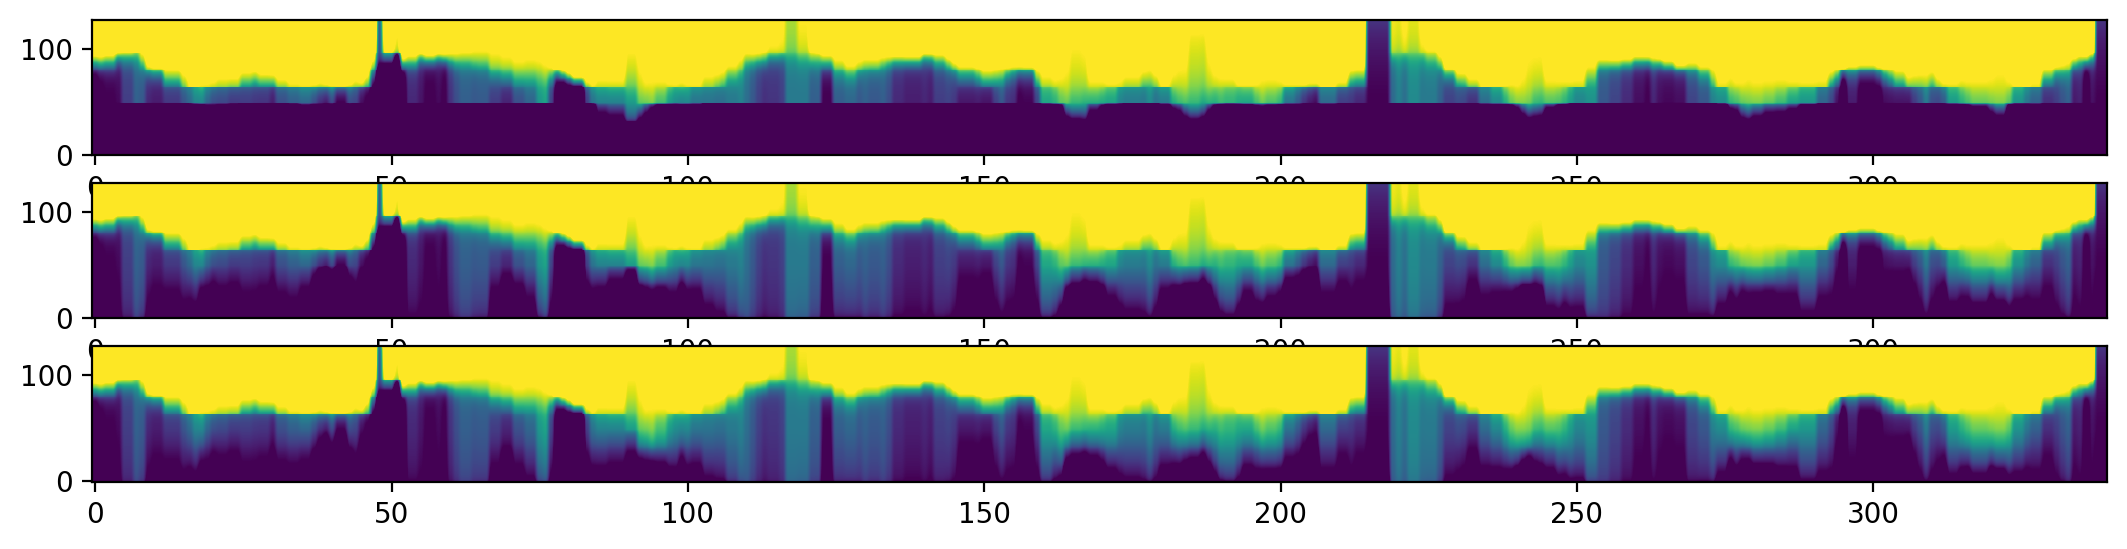

In [337]:
solver.plot_replication_hm(normalize=False, mask=False) # gamma 0.002

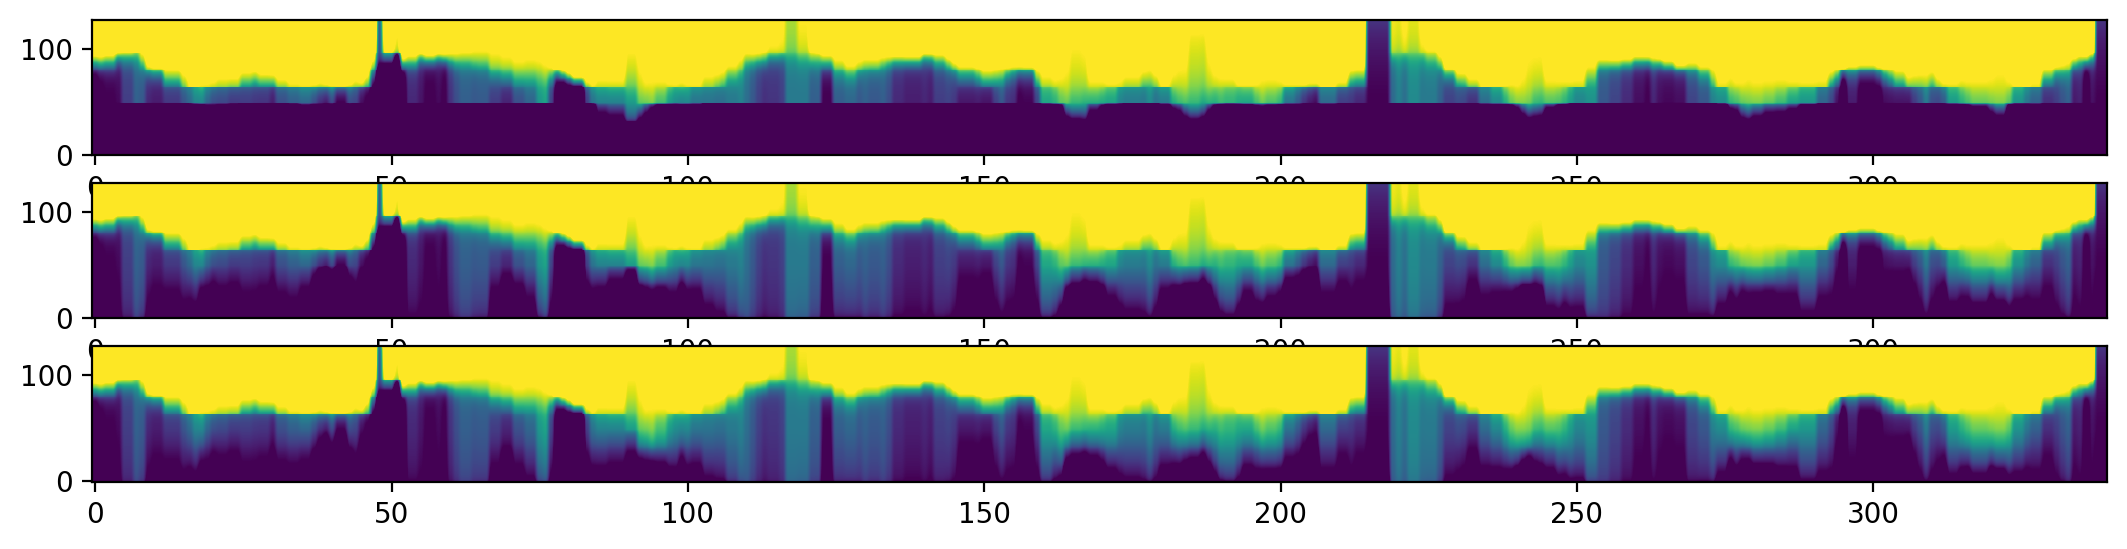

In [341]:
solver.plot_replication_hm(normalize=False, mask=False) # gamma 0.001

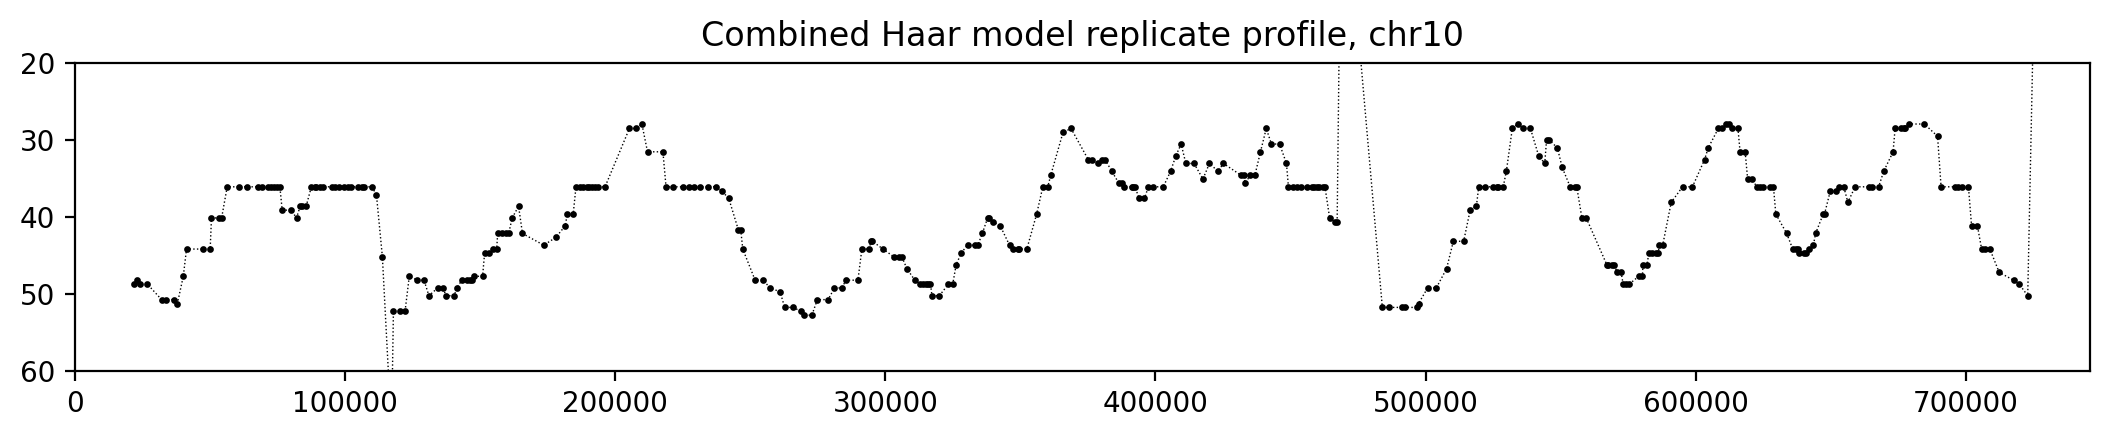

In [340]:
solver.plot_replication_timing(chr_genes, chrom)

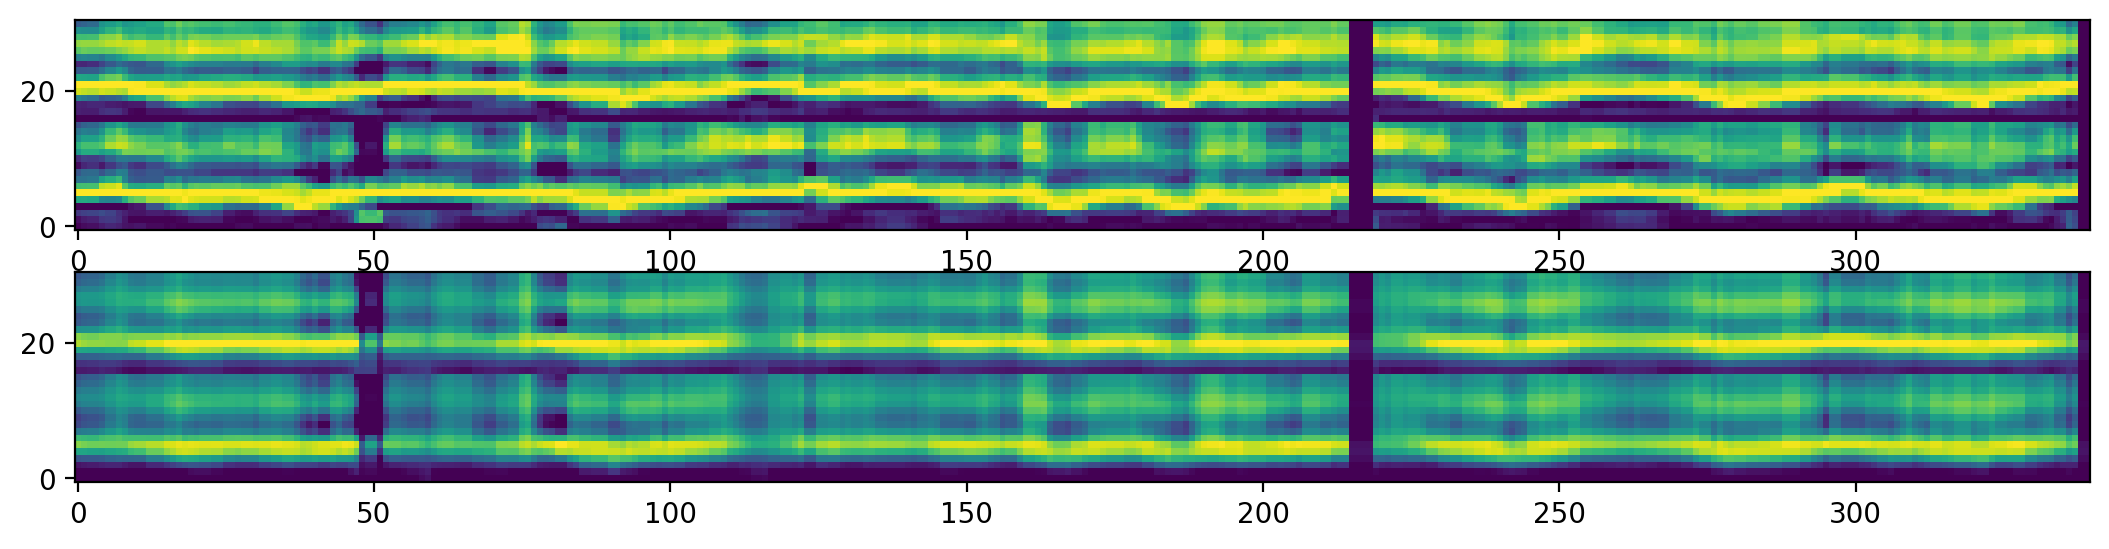

In [262]:
solver.plot_raw_predicted()